In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

df = pd.read_csv(r"c:\Users\Huawei\OneDrive\Desktop\projects\EDA-s\train_data.csv")
print(df.shape)
df.head()

(7831, 3)


,Tweet_ID,Tweet,Label
0,1,#الرياض #أمطار_الرياض #السعودية #مطر #الرياض_ت...,OBJ
1,2,من بين الأسماء محمود القرش، مصر الجديدة وآخرين...,OBJ
2,3,مقتل طفلة لبنانية في تبادل إطلاق نار بين علويي...,OBJ
3,4,#الروح_و_الجسد #مصطفي_محمود,OBJ
4,5,دعبد المنعم أبو الفتوح فى عيون العالم,OBJ


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Tweet_ID  7831 non-null   int64 
 1   Tweet     7831 non-null   object
 2   Label     7831 non-null   object
dtypes: int64(1), object(2)
memory usage: 183.7+ KB


In [4]:
print("\nMissing values:\n", df.isnull().sum())




Missing values:
 Tweet_ID    0
Tweet       0
Label       0
dtype: int64


In [5]:
df["Label"].value_counts()



Label
OBJ        5233
NEG        1317
NEUTRAL     654
POS         627
Name: count, dtype: int64

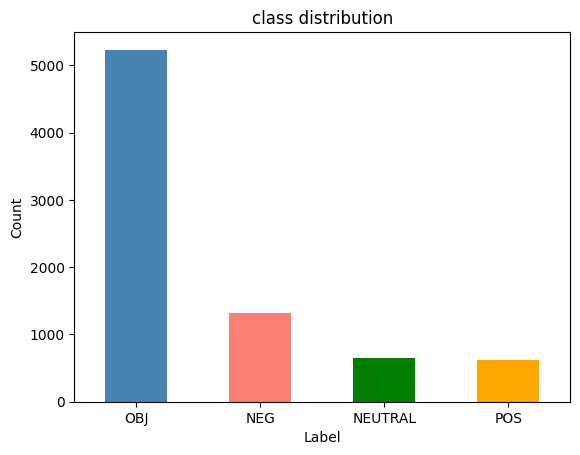

In [6]:
df["Label"].value_counts().plot(kind="bar", color=["steelblue","salmon","green","orange"])
plt.title("class distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


### Tweet length

In [7]:
# tweet length
df["tweet_length"] = df["Tweet"].apply(len)

# average tweet length by label
df.groupby("Label")["tweet_length"].mean().round(0)


Label
NEG         93.0
NEUTRAL    103.0
OBJ         79.0
POS         77.0
Name: tweet_length, dtype: float64

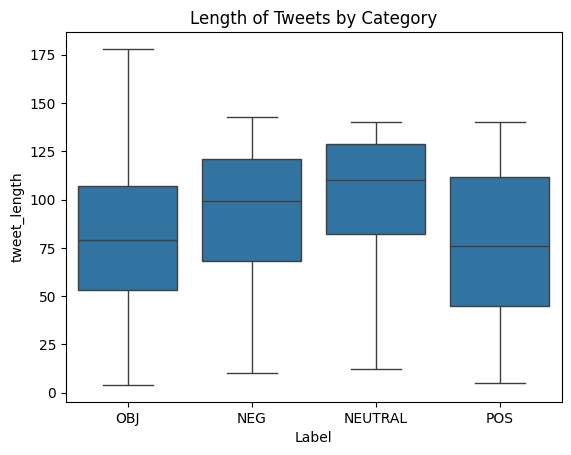

In [8]:
# boxplot of tweet length by label
sns.boxplot(x="Label", y="tweet_length", data=df)
plt.title("Length of Tweets by Category")
plt.show()


In [9]:
from collections import Counter

for label in df["Label"].unique():
    tweets = " ".join(df[df["Label"] == label]["Tweet"])
    words = tweets.split()
    common = Counter(words).most_common(10)
    print(f"\n--- {label} ---")
    for word, count in common:
        print(f"{word}: {count}")



--- OBJ ---
في: 1288
من: 1160
على: 850
و: 692
-: 481
#: 477
فى: 341
عن: 326
مع: 324
…: 321

--- NEG ---
من: 400
في: 362
على: 262
و: 195
فى: 150
لا: 134
عن: 115
مصر: 111
ما: 98
كل: 95

--- NEUTRAL ---
من: 230
في: 194
و: 123
على: 121
لا: 78
ان: 74
عن: 57
مع: 53
مصر: 48
كل: 48

--- POS ---
في: 176
من: 152
و: 116
الله: 90
على: 87
يا: 53
كل: 44
فى: 43
مصر: 42
لا: 39


In [10]:
!pip install camel-tools



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Huawei\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
import re
from collections import Counter

# stopwords عربية بسيطة
stopwords = set([
    "في","من","على","و","عن","مع","إلى","هذا","هذه","التي","الذي",
    "كان","لا","ما","كل","قد","أن","إن","لم","عند","حتى","أو","كما",
    "هو","هي","هم","نحن","أنا","لي","له","لها","بعد","قبل","حين","ثم"
])

def clean_text(text):
    text = re.sub(r"http\S+|#\S+|@\S+|[^\w\s]|[a-zA-Z]|\d", " ", str(text))
    words = text.split()
    return [w for w in words if w not in stopwords and len(w) > 2]

for label in ["OBJ", "NEG", "NEUTRAL", "POS"]:
    words = []
    for tweet in df[df["Label"] == label]["Tweet"]:
        words.extend(clean_text(tweet))
    common = Counter(words).most_common(10)
    print(f"\n--- {label} ---")
    for word, count in common:
        print(f"{word}: {count}")



--- OBJ ---
مصر: 260
الله: 246
اليوم: 205
كلام: 199
آخر: 196
شاهد: 187
اللي: 145
عمرو: 133
عبد: 127
الفتوح: 123

--- NEG ---
مصر: 113
الانقلاب: 74
اللي: 71
مرسي: 68
الاخوان: 59
ولا: 55
الى: 48
الإخوان: 43
اليوم: 37
الناس: 35

--- NEUTRAL ---
مصر: 48
مرسي: 45
اللي: 41
ولا: 36
الله: 36
الشعب: 35
الثورة: 34
الانقلاب: 28
الاخوان: 26
الإخوان: 26

--- POS ---
الله: 92
مصر: 44
اللي: 22
الشعب: 22
اليوم: 22
ولا: 21
يوم: 18
جدا: 16
بين: 15
الثورة: 14


### data are immbalanced to eagybt

In [12]:
!pip install wordcloud arabic-reshaper python-bidi



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Huawei\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


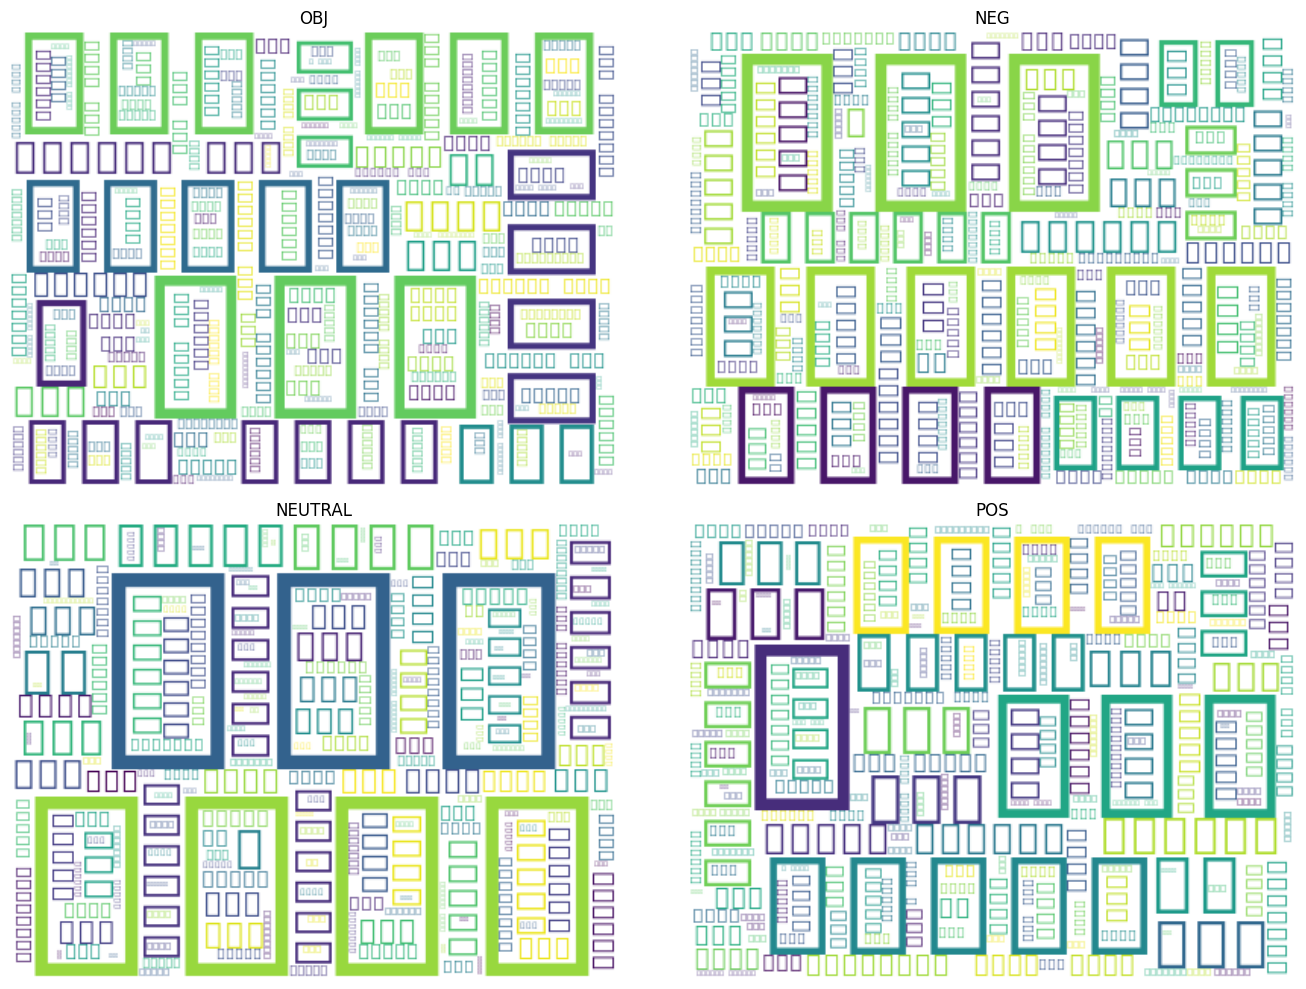

In [13]:
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, label in zip(axes.flatten(), ["OBJ", "NEG", "NEUTRAL", "POS"]):
    words = []
    for tweet in df[df["Label"] == label]["Tweet"]:
        words.extend(clean_text(tweet))
    text = " ".join(words)
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    wc = WordCloud(width=400, height=300, background_color="white").generate(bidi_text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()


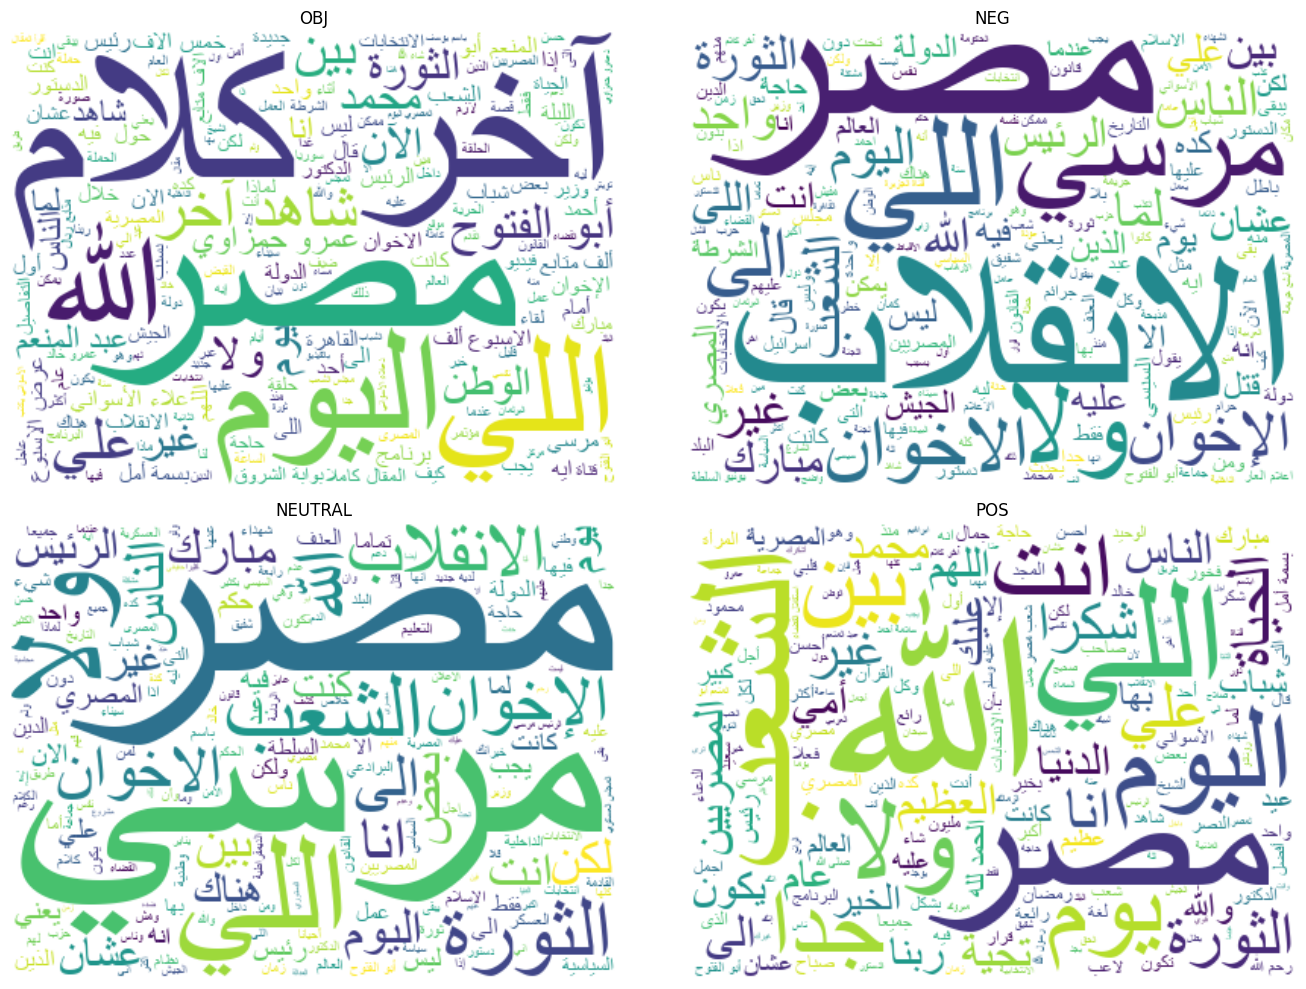

In [14]:
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.pyplot as plt

# حمّلي خط عربي - استخدمي أي خط موجود على ويندوز
font_path = r"C:\Windows\Fonts\arial.ttf"

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, label in zip(axes.flatten(), ["OBJ", "NEG", "NEUTRAL", "POS"]):
    words = []
    for tweet in df[df["Label"] == label]["Tweet"]:
        words.extend(clean_text(tweet))
    text = " ".join(words)
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    
    wc = WordCloud(
        font_path=font_path,  # ← هذا هو الحل
        width=400, height=300,
        background_color="white"
    ).generate(bidi_text)
    
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [15]:
import re

def clean_arabic(text):
    text = str(text)
    text = re.sub(r"http\S+", " ", text)        # روابط
    text = re.sub(r"@\S+", " ", text)           # منشنز
    text = re.sub(r"#", " ", text)              # رمز الهاشتاق بس
    text = re.sub(r"[إأآا]", "ا", text)         # توحيد الألف
    text = re.sub(r"ة", "ه", text)              # توحيد التاء المربوطة
    text = re.sub(r"ى", "ي", text)              # توحيد الياء
    text = re.sub(r"[\u064B-\u065F]", "", text) # إزالة التشكيل
    text = re.sub(r"[^\w\s]", " ", text)        # علامات الترقيم
    text = re.sub(r"[a-zA-Z0-9]", " ", text)   # إنجليزي وأرقام
    text = re.sub(r"\s+", " ", text).strip()    # مسافات زيادة
    return text

df["clean_tweet"] = df["Tweet"].apply(clean_arabic)
df[["Tweet", "clean_tweet"]].head(5)



,Tweet,clean_tweet
0,#الرياض #أمطار_الرياض #السعودية #مطر #الرياض_ت...,الرياض امطار_الرياض السعوديه مطر الرياض_تغرق ا...
1,من بين الأسماء محمود القرش، مصر الجديدة وآخرين...,من بين الاسماء محمود القرش مصر الجديده واخرين ...
2,مقتل طفلة لبنانية في تبادل إطلاق نار بين علويي...,مقتل طفله لبنانيه في تبادل اطلاق نار بين علويي...
3,#الروح_و_الجسد #مصطفي_محمود,الروح_و_الجسد مصطفي_محمود
4,دعبد المنعم أبو الفتوح فى عيون العالم,دعبد المنعم ابو الفتوح في عيون العالم


In [16]:
def clean_arabic(text):
    text = str(text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\S+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"_", " ", text)              # ← أضيفي هذا السطر
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ة", "ه", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"[\u064B-\u065F]", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"[a-zA-Z0-9]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_tweet"] = df["Tweet"].apply(clean_arabic)
df[["Tweet", "clean_tweet"]].head(5)


,Tweet,clean_tweet
0,#الرياض #أمطار_الرياض #السعودية #مطر #الرياض_ت...,الرياض امطار الرياض السعوديه مطر الرياض تغرق ا...
1,من بين الأسماء محمود القرش، مصر الجديدة وآخرين...,من بين الاسماء محمود القرش مصر الجديده واخرين ...
2,مقتل طفلة لبنانية في تبادل إطلاق نار بين علويي...,مقتل طفله لبنانيه في تبادل اطلاق نار بين علويي...
3,#الروح_و_الجسد #مصطفي_محمود,الروح و الجسد مصطفي محمود
4,دعبد المنعم أبو الفتوح فى عيون العالم,دعبد المنعم ابو الفتوح في عيون العالم


In [17]:
stopwords = set([
    "في","من","على","و","عن","مع","إلى","هذا","هذه","التي","الذي",
    "كان","لا","ما","كل","قد","أن","إن","لم","عند","حتى","أو","كما",
    "هو","هي","هم","نحن","انا","لي","له","لها","بعد","قبل","حين","ثم",
    "اي","اذا","عليه","عليها","فيه","فيها","منه","منها","كانت","يكون"
])

def remove_stopwords(text):
    words = text.split()
    return " ".join([w for w in words if w not in stopwords and len(w) > 2])

df["final_tweet"] = df["clean_tweet"].apply(remove_stopwords)
df[["Tweet", "clean_tweet", "final_tweet"]]


,Tweet,clean_tweet,final_tweet
0,#الرياض #أمطار_الرياض #السعودية #مطر #الرياض_ت...,الرياض امطار الرياض السعوديه مطر الرياض تغرق ا...,الرياض امطار الرياض السعوديه مطر الرياض تغرق ا...
1,من بين الأسماء محمود القرش، مصر الجديدة وآخرين...,من بين الاسماء محمود القرش مصر الجديده واخرين ...,بين الاسماء محمود القرش مصر الجديده واخرين وال...
2,مقتل طفلة لبنانية في تبادل إطلاق نار بين علويي...,مقتل طفله لبنانيه في تبادل اطلاق نار بين علويي...,مقتل طفله لبنانيه تبادل اطلاق نار بين علويين وسنه
3,#الروح_و_الجسد #مصطفي_محمود,الروح و الجسد مصطفي محمود,الروح الجسد مصطفي محمود
4,دعبد المنعم أبو الفتوح فى عيون العالم,دعبد المنعم ابو الفتوح في عيون العالم,دعبد المنعم ابو الفتوح عيون العالم
...,...,...,...
7826,بعد قليل تبدأ الندوة الأسبوعية دعلاء الأسواني ...,بعد قليل تبدا الندوه الاسبوعيه دعلاء الاسواني ...,قليل تبدا الندوه الاسبوعيه دعلاء الاسواني مركز...
7827,#الجامعة_العربية تؤكد دعمها #للرئيس في مواجهة ...,الجامعه العربيه تؤكد دعمها للرئيس في مواجهه ال...,الجامعه العربيه تؤكد دعمها للرئيس مواجهه الضغو...
7828,يجب على كل ابناء #الزمالك مساندة ميدو ودعمه بش...,يجب علي كل ابناء الزمالك مسانده ميدو ودعمه بشك...,يجب علي ابناء الزمالك مسانده ميدو ودعمه بشكل ك...
7829,اشتموا و قلوا أدبكم كمان وكمان خلينا نتعرف على...,اشتموا و قلوا ادبكم كمان وكمان خلينا نتعرف علي...,اشتموا قلوا ادبكم كمان وكمان خلينا نتعرف علي ا...


In [18]:
stopwords = set([
    "في","من","على","و","عن","مع","إلى","هذا","هذه","التي","الذي",
    "كان","قد","أن","إن","لم","عند","حتى","أو","كما",
    "هو","هي","هم","نحن","انا","لي","له","لها","بعد","قبل","حين","ثم",
    "اي","اذا","عليه","عليها","فيه","فيها","منه","منها","كانت","يكون"
    # حذفنا "لا" و "ما" لأنهم يحملون معنى
])


In [19]:
df["final_tweet"] = df["clean_tweet"].apply(remove_stopwords)
df[["Tweet", "clean_tweet", "final_tweet"]]


,Tweet,clean_tweet,final_tweet
0,#الرياض #أمطار_الرياض #السعودية #مطر #الرياض_ت...,الرياض امطار الرياض السعوديه مطر الرياض تغرق ا...,الرياض امطار الرياض السعوديه مطر الرياض تغرق ا...
1,من بين الأسماء محمود القرش، مصر الجديدة وآخرين...,من بين الاسماء محمود القرش مصر الجديده واخرين ...,بين الاسماء محمود القرش مصر الجديده واخرين وال...
2,مقتل طفلة لبنانية في تبادل إطلاق نار بين علويي...,مقتل طفله لبنانيه في تبادل اطلاق نار بين علويي...,مقتل طفله لبنانيه تبادل اطلاق نار بين علويين وسنه
3,#الروح_و_الجسد #مصطفي_محمود,الروح و الجسد مصطفي محمود,الروح الجسد مصطفي محمود
4,دعبد المنعم أبو الفتوح فى عيون العالم,دعبد المنعم ابو الفتوح في عيون العالم,دعبد المنعم ابو الفتوح عيون العالم
...,...,...,...
7826,بعد قليل تبدأ الندوة الأسبوعية دعلاء الأسواني ...,بعد قليل تبدا الندوه الاسبوعيه دعلاء الاسواني ...,قليل تبدا الندوه الاسبوعيه دعلاء الاسواني مركز...
7827,#الجامعة_العربية تؤكد دعمها #للرئيس في مواجهة ...,الجامعه العربيه تؤكد دعمها للرئيس في مواجهه ال...,الجامعه العربيه تؤكد دعمها للرئيس مواجهه الضغو...
7828,يجب على كل ابناء #الزمالك مساندة ميدو ودعمه بش...,يجب علي كل ابناء الزمالك مسانده ميدو ودعمه بشك...,يجب علي ابناء الزمالك مسانده ميدو ودعمه بشكل ك...
7829,اشتموا و قلوا أدبكم كمان وكمان خلينا نتعرف على...,اشتموا و قلوا ادبكم كمان وكمان خلينا نتعرف علي...,اشتموا قلوا ادبكم كمان وكمان خلينا نتعرف علي ا...


In [20]:
sample = df[df["Tweet"].str.contains("لا")][["Tweet", "final_tweet"]]
print(sample.to_string())


                                                                                                                                                                                   Tweet                                                                                                                                                           final_tweet
1                                             من بين الأسماء محمود القرش، مصر الجديدة وآخرين والحالات تتابع المعلومات التي أنشرها غير سرية وعلى المحامين السؤال في النيابات حول الداخلية                                        بين الاسماء محمود القرش مصر الجديده واخرين والحالات تتابع المعلومات انشرها غير سريه وعلي المحامين السؤال النيابات حول الداخليه
2                                                                                                                                   مقتل طفلة لبنانية في تبادل إطلاق نار بين علويين وسنة                                                                                                                  

1. تحويل النصوص إلى أرقام (Feature Extraction)

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
x = vectorizer.fit_transform(df["final_tweet"]).toarray()
y = df["Label"].values

2.تقسيم البيانات 

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

3.Model Train

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

4. predict

In [28]:
y_pred = model.predict(X_test)

5.Evaluatinig 

In [29]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.6790044671346522
              precision    recall  f1-score   support

         NEG       0.48      0.14      0.22       264
     NEUTRAL       0.50      0.04      0.07       131
         OBJ       0.69      0.97      0.81      1047
         POS       0.56      0.04      0.07       125

    accuracy                           0.68      1567
   macro avg       0.56      0.30      0.29      1567
weighted avg       0.63      0.68      0.59      1567



6.cofusion matrix

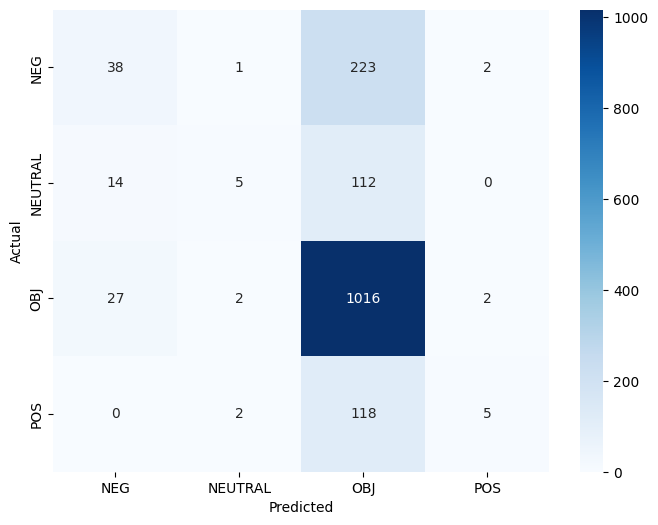

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

7.more than model

Logistic Regression

Naive Bayes

Random Forest

SVM

In [31]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)